In [1]:
import numpy as np
import matplotlib
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import re

In [3]:
df1 = pd.read_csv("/home/wenyuantong/Downloads/class_unassigned.txt", header = None)
display(df1.head())

,0
0,A0A1P8B415_N-terminal_1_66
1,F4JTS9_N-terminal_1_58
2,O64583_N-terminal_1_78
3,O64764_N-terminal_1_84
4,P42753_C-terminal_295_376


In [11]:
df1

,0,ID_part
0,A0A1P8B415_N-terminal_1_66,A0A1P8B415
1,F4JTS9_N-terminal_1_58,F4JTS9
2,O64583_N-terminal_1_78,O64583
3,O64764_N-terminal_1_84,O64764
4,P42753_C-terminal_295_376,P42753
...,...,...
8395,Q9SQV1_N-terminal_1_416,Q9SQV1
8396,Q9STN0_IDP_1_437,Q9STN0
8397,Q9T0L0_IDP_1_429,Q9T0L0
8398,Q9FS16_IDP_1_431,Q9FS16


In [6]:
df1['ID_part'] = df1.iloc[:, 0].astype(str).str.split('_').str[0]

In [7]:
display(df1.head())

,0,ID_part
0,A0A1P8B415_N-terminal_1_66,A0A1P8B415
1,F4JTS9_N-terminal_1_58,F4JTS9
2,O64583_N-terminal_1_78,O64583
3,O64764_N-terminal_1_84,O64764
4,P42753_C-terminal_295_376,P42753


In [9]:
id_part_list = df1['ID_part'].tolist()
id_part_list = list(set(id_part_list))
#print(id_part_list)

In [15]:
id_part_list = df1[0].tolist()
id_part_list = list(set(id_part_list))
#print(id_part_list)

In [10]:
combined_df = pd.read_csv("/home/wenyuantong/Desktop/data/arabi_cross/merge_50_450.csv", index_col=0)
display(combined_df.head())

,A0A1P8B415_N-terminal_1_66,F4I316_middle_415_496,F4IRU3_middle_1071_1134,F4IRU3_middle_1221_1270,F4JN22_middle_193_249,F4JRR2_N-terminal_1_90,F4JRR2_middle_423_483,F4JRR2_C-terminal_1055_1122,F4JTS9_N-terminal_1_58,F4KGY0_N-terminal_1_74,...,Q9FMZ3_middle_209_641,F4HRT5_C-terminal_721_1132,F4HZ48_N-terminal_1_407,Q9LTX1_middle_95_501,Q9FPW4_N-terminal_1_434,Q9LF34_IDP_1_402,F4ICK6_middle_482_919,Q9FLK7_N-terminal_1_425,O23088_IDP_1_431,Q9FFP2_C-terminal_72_492
A0A1P8B415_N-terminal_1_66,1.119008,0.802352,0.399740,-0.079631,3.848794,0.770273,0.320466,-0.570105,0.989400,0.767606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
F4I316_middle_415_496,0.645795,4.757276,3.261071,1.155957,3.602020,5.560720,3.801985,2.011505,1.163882,2.383556,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
F4IRU3_middle_1071_1134,0.412232,4.178247,2.850836,1.128669,3.563362,5.396121,3.583882,1.732982,1.014273,2.119811,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
F4IRU3_middle_1221_1270,-0.105113,1.895770,1.444696,0.200578,3.149860,3.027413,2.001373,0.081988,0.523915,0.935924,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
F4JN22_middle_193_249,4.456498,5.181853,4.000967,2.763035,5.846211,6.101167,4.089311,3.203667,3.806800,4.675769,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
# Combine substrings into a single regex pattern using '|' (OR operator)
# This pattern will match if any of the substrings are found.
# Using re.escape to handle potential regex special characters in substrings
search_pattern = '|'.join([re.escape(s) for s in id_part_list])

# Identify columns to keep based on partial match
# The boolean mask is created using .str.contains
columns_to_keep_mask = combined_df.columns.str.contains(search_pattern, case=False, regex=True)
columns_to_keep = combined_df.columns[columns_to_keep_mask].tolist()

# Identify rows to keep based on partial match
rows_to_keep_mask = combined_df.index.str.contains(search_pattern, case=False, regex=True)
rows_to_keep = combined_df.index[rows_to_keep_mask].tolist()

# Filter the DataFrame to keep only the identified columns and rows
# First, select columns, then select rows from the resulting DataFrame
df_filtered_partial = combined_df.loc[rows_to_keep, columns_to_keep]

#print(f"\nSubstrings to match and keep: {substrings_to_keep}")
#print(f"Columns identified for keeping: {columns_to_keep}")
#print(f"Rows identified for keeping: {rows_to_keep}")
print(f"\nDataFrame after keeping columns and rows with partial label matches:")
display(df_filtered_partial)


DataFrame after keeping columns and rows with partial label matches:


,A0A1P8B415_N-terminal_1_66,F4JTS9_N-terminal_1_58,O64583_N-terminal_1_78,O64764_N-terminal_1_84,P42753_C-terminal_295_376,Q5PP12_IDP_1_69,Q8L9H6_IDP_1_99,Q8LAF9_C-terminal_153_202,Q8RXJ5_N-terminal_1_51,Q8RXJ5_middle_132_202,...,F4I9Q5_N-terminal_1_374,Q95749_N-terminal_1_443,Q94F54_N-terminal_1_423,Q9C669_IDP_1_443,F4K3X4_IDP_1_440,Q9SQV1_N-terminal_1_416,Q9STN0_IDP_1_437,Q9T0L0_IDP_1_429,Q9FS16_IDP_1_431,Q5BPU6_IDP_1_420
A0A1P8B415_N-terminal_1_66,1.119008,0.989400,-1.184877,1.594853,1.137402,1.751652,-0.088289,1.711129,3.608467,-3.581934,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
F4JTS9_N-terminal_1_58,1.125869,0.900071,-0.662382,1.945379,1.912528,1.084983,-0.151511,2.141182,2.841918,-2.506521,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
O64583_N-terminal_1_78,-1.002588,-0.492540,6.611041,0.321143,2.148265,1.753120,-2.067999,2.584984,-2.987557,3.178498,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
O64764_N-terminal_1_84,1.253098,1.343238,0.298204,2.433777,2.584179,2.352509,0.362956,2.219268,2.929456,-2.164674,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P42753_C-terminal_295_376,0.915470,1.352764,2.043471,2.647207,3.209504,3.034099,0.348542,2.571664,1.689898,-0.821227,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Q9SQV1_N-terminal_1_416,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,-7.891077,-15.768860,-26.607306,-23.598044,-13.559134,-27.757807,-20.509538,-14.973606,-14.589532
Q9STN0_IDP_1_437,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,-19.899293,-28.679421,-38.270794,-35.732515,-26.423907,-39.944291,-31.262573,-29.363449,-26.972119
Q9T0L0_IDP_1_429,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,-13.191940,-22.579406,-30.158803,-27.473134,-19.888036,-31.845558,-24.122031,-20.016172,-20.707483
Q9FS16_IDP_1_431,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,3.469194,-22.383975,-27.805764,-18.007003,-14.452483,-29.772221,-19.923290,4.678357,-15.327943


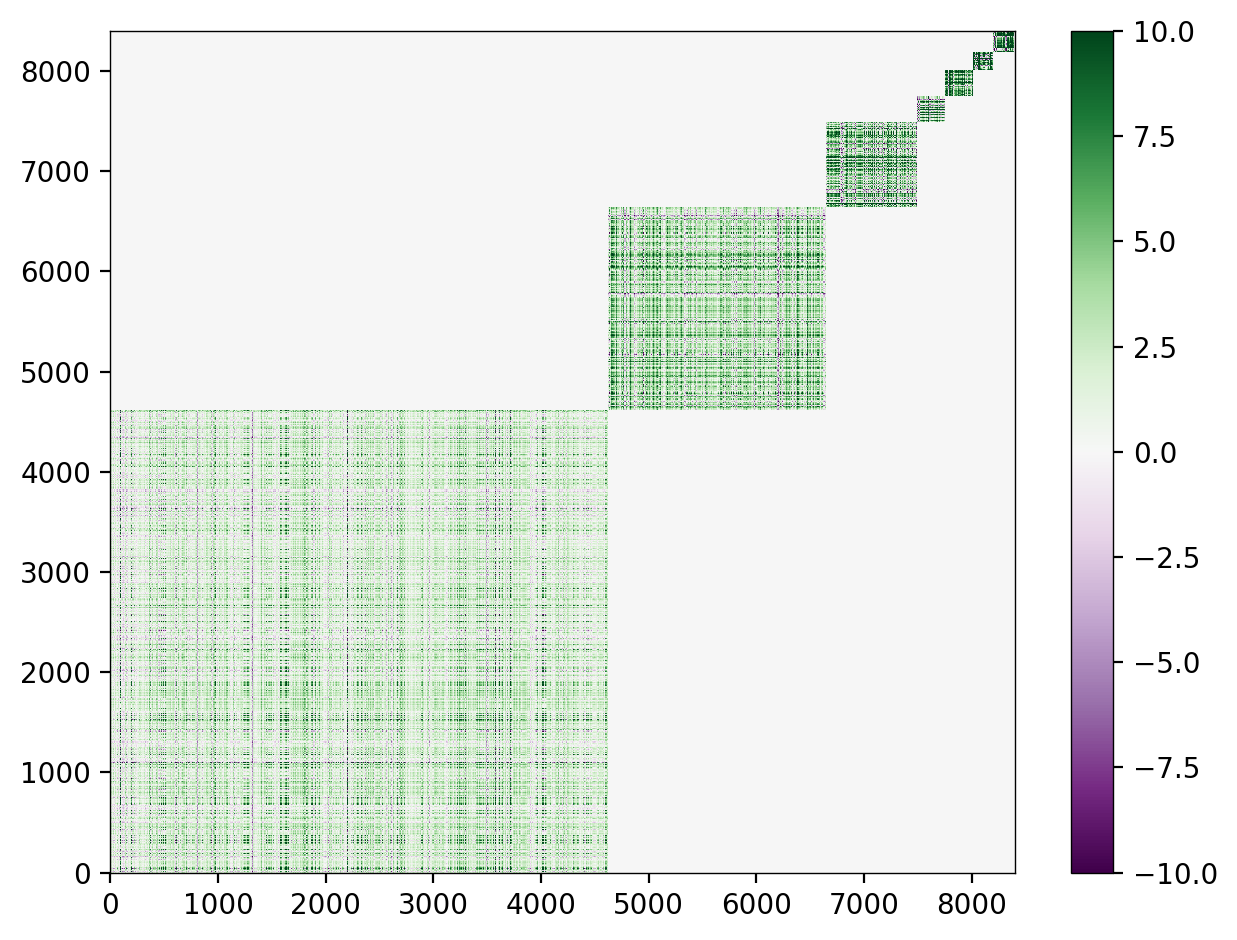

In [114]:
# test-drive simple representation - 
if mode == 'calvados':
    plt.imshow(reordered_matrix, vmin=-25, vmax=25,cmap='PRGn',interpolation='None', aspect='auto', origin='lower')
    plt.colorbar()
    plt.tight_layout()
elif mode == 'mpipi':
    plt.imshow(df_filtered_partial.values, vmin=-10, vmax=10,cmap='PRGn',interpolation='None', aspect='auto', origin='lower')
    plt.colorbar()
    #plt.show()
    plt.tight_layout()
    plt.savefig(f'/home/wenyuantong/Desktop/figures/original_unknown_matrix_{mode}.pdf')

In [17]:
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
	
# Set such that PDF fonts export in a manner that they
# are editable in illustrator/affinity
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# set to define axes linewidths
matplotlib.rcParams['axes.linewidth'] = 0.5

# this defines some prefactors so inline figures look nice
# on a retina macbook. These can be commented out without any
# issue and are solely asthetic.
%matplotlib inline
%config InlineBackend.figure_format='retina'

# UPDATE 2020-12-31 (my preferred font is Avenir...)
font = {'family' : 'avenir',
    	'weight' : 'normal'}

matplotlib.rc('font', **font)

from tqdm import tqdm
import pickle
from sparrow import Protein
import protfasta
from tqdm.auto import tqdm

In [18]:
from shephard.apis import uniprot
from shephard.interfaces import si_domains, si_protein_attributes

from finches import Mpipi_frontend, CALVADOS_frontend
mf = Mpipi_frontend()
cf = CALVADOS_frontend()

/home/wenyuantong/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/finches/forcefields/calvados.py:236: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.038286503882254706' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  r.loc['H','q'] = 1. / ( 1 + 10**(self.pH-6) )


In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list,fcluster
import matplotlib.patches as mpatches

In [20]:
font = {'family' : 'sans-serif',
    	'weight' : 'normal'}

matplotlib.rc('font', **font)

In [21]:
mode='mpipi'

In [22]:
%%time
# calculate the linkage relationships
# NOTE - this takes ~5 min to run because of the optimal_ordering keyword
row_linkage = linkage(df_filtered_partial, method='ward', optimal_ordering=True)
col_linkage = linkage(df_filtered_partial.T, method='ward',optimal_ordering=True)  # Transpose for column clustering
row_order = leaves_list(row_linkage)
col_order = leaves_list(col_linkage)

CPU times: user 3h 12min 57s, sys: 26.4 s, total: 3h 13min 23s
Wall time: 3h 12min 25s


In [45]:
row_order

array([3404, 3045, 2204, ..., 5481, 5802, 5172],
      shape=(8400,), dtype=int32)

In [43]:

df_numbered_indices = df_filtered_partial.copy()
df_numbered_indices.index = range(len(df_numbered_indices.index)) # Assign new numerical row index
df_numbered_indices.columns = range(len(df_numbered_indices.columns)) # Assign new numerical column index

print("\nNew DataFrame with numerical indices:")
display(df_numbered_indices)


New DataFrame with numerical indices:


,0,1,2,3,4,5,6,7,8,9,...,8390,8391,8392,8393,8394,8395,8396,8397,8398,8399
0,1.119008,0.989400,-1.184877,1.594853,1.137402,1.751652,-0.088289,1.711129,3.608467,-3.581934,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1.125869,0.900071,-0.662382,1.945379,1.912528,1.084983,-0.151511,2.141182,2.841918,-2.506521,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,-1.002588,-0.492540,6.611041,0.321143,2.148265,1.753120,-2.067999,2.584984,-2.987557,3.178498,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1.253098,1.343238,0.298204,2.433777,2.584179,2.352509,0.362956,2.219268,2.929456,-2.164674,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.915470,1.352764,2.043471,2.647207,3.209504,3.034099,0.348542,2.571664,1.689898,-0.821227,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,-7.891077,-15.768860,-26.607306,-23.598044,-13.559134,-27.757807,-20.509538,-14.973606,-14.589532
8396,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,-19.899293,-28.679421,-38.270794,-35.732515,-26.423907,-39.944291,-31.262573,-29.363449,-26.972119
8397,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,-13.191940,-22.579406,-30.158803,-27.473134,-19.888036,-31.845558,-24.122031,-20.016172,-20.707483
8398,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,3.469194,-22.383975,-27.805764,-18.007003,-14.452483,-29.772221,-19.923290,4.678357,-15.327943


In [46]:
# Check the dtype of your DataFrame's index
df_index_dtype = df_numbered_indices.index.dtype
print(f"DataFrame index dtype: {df_index_dtype}")

DataFrame index dtype: int64


In [47]:
compatible_row_order = pd.Index(row_order, dtype=df_index_dtype)

In [48]:
compatible_col_order = pd.Index(col_order, dtype=df_index_dtype)

In [50]:
# reorder the matrix based on this set of linkage relationships
#reordered_matrix = data[row_order, :][:, col_order]
#reordered_matrix = df_filtered_partial.reindex(index=row_order, columns=col_order)
reordered_matrix =  df_numbered_indices.loc[compatible_row_order, compatible_col_order]

In [51]:
reordered_matrix

,3404,4089,2204,4582,3045,4201,97,1549,1531,2783,...,5054,5876,6220,5584,6195,5815,4629,6122,5802,5172
3404,120.721380,96.939343,94.455906,89.253130,89.737834,82.638337,73.815435,71.543812,63.057010,63.939291,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3045,108.489023,87.550436,85.273591,80.696100,80.808053,74.869788,66.756202,64.885436,57.147610,58.446643,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2204,99.362706,80.647765,78.251087,74.141332,74.199098,68.862461,61.425063,59.769596,52.613004,53.820124,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4582,85.052983,69.432194,67.163325,63.647482,63.607514,59.280952,52.866548,51.478692,45.389011,46.422151,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3445,87.897245,71.860271,69.483786,65.961370,65.793989,61.347104,54.729227,53.326229,47.114824,48.319950,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5815,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.392375,-0.051305,-0.193547,-0.591286,-1.404411,1.062025,0.962781,0.204562,2.240815,5.819929
4629,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.080662,0.067721,-0.233752,-0.917207,-1.740539,0.825241,0.597315,-0.215616,1.795318,5.196429
5481,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.466058,0.592246,0.373809,-0.648714,-1.297464,1.429231,1.155608,0.271196,2.318996,5.524561
5802,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.800406,0.368699,0.323789,-0.495478,-1.043099,2.188703,2.045827,1.238477,4.166049,8.528549


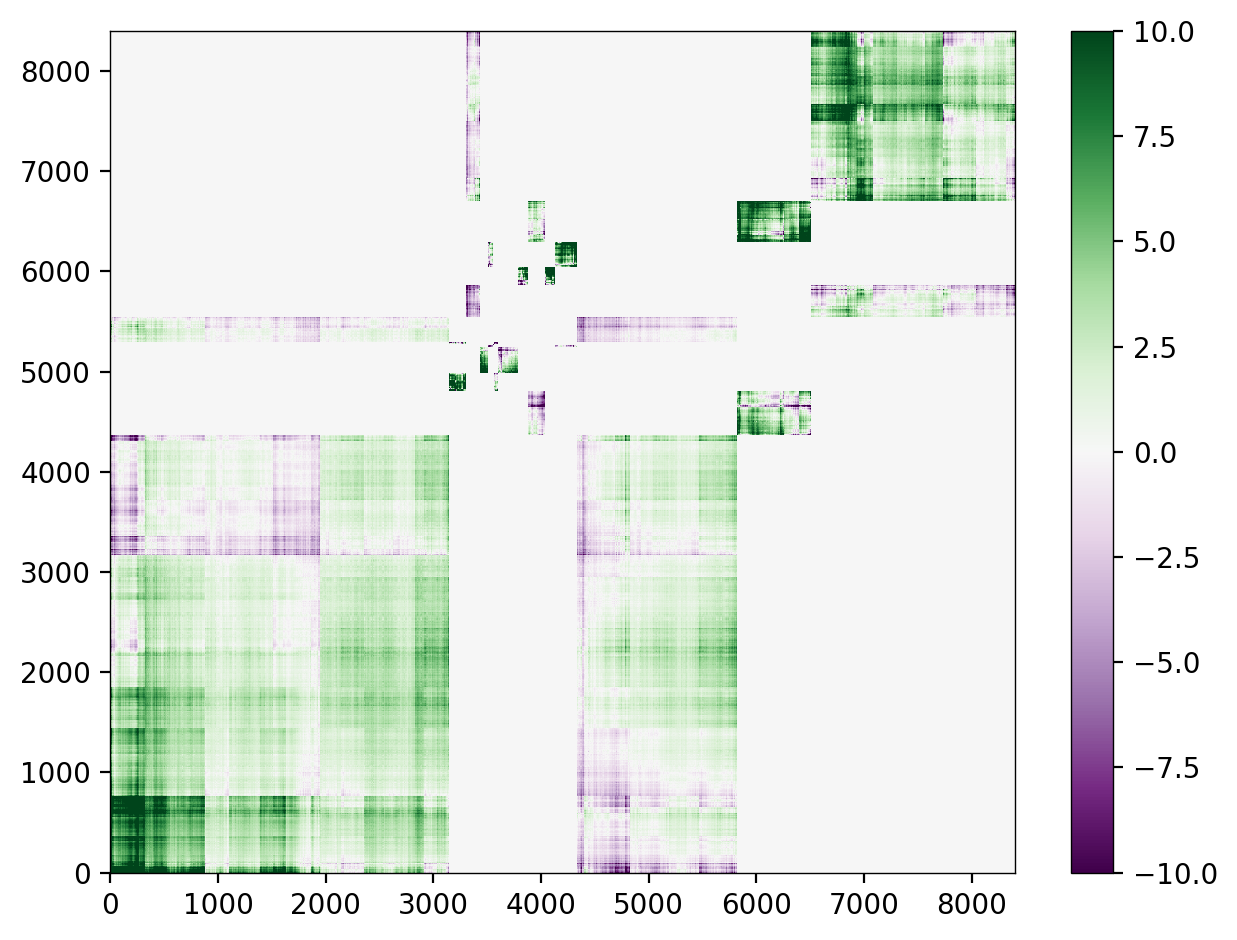

In [115]:
# test-drive simple representation - 
if mode == 'calvados':
    plt.imshow(reordered_matrix, vmin=-25, vmax=25,cmap='PRGn',interpolation='None', aspect='auto', origin='lower')
    plt.colorbar()
    plt.tight_layout()
elif mode == 'mpipi':
    plt.imshow(reordered_matrix.values, vmin=-10, vmax=10,cmap='PRGn',interpolation='None', aspect='auto', origin='lower')
    plt.colorbar()
    #plt.show()
    plt.tight_layout()
    plt.savefig(f'/home/wenyuantong/Desktop/figures/cluster_unknown_matrix_{mode}.pdf')
    

Sample DataFrame head:


,3404,4089,2204,4582,3045,4201,97,1549,1531,2783,...,5054,5876,6220,5584,6195,5815,4629,6122,5802,5172
3404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


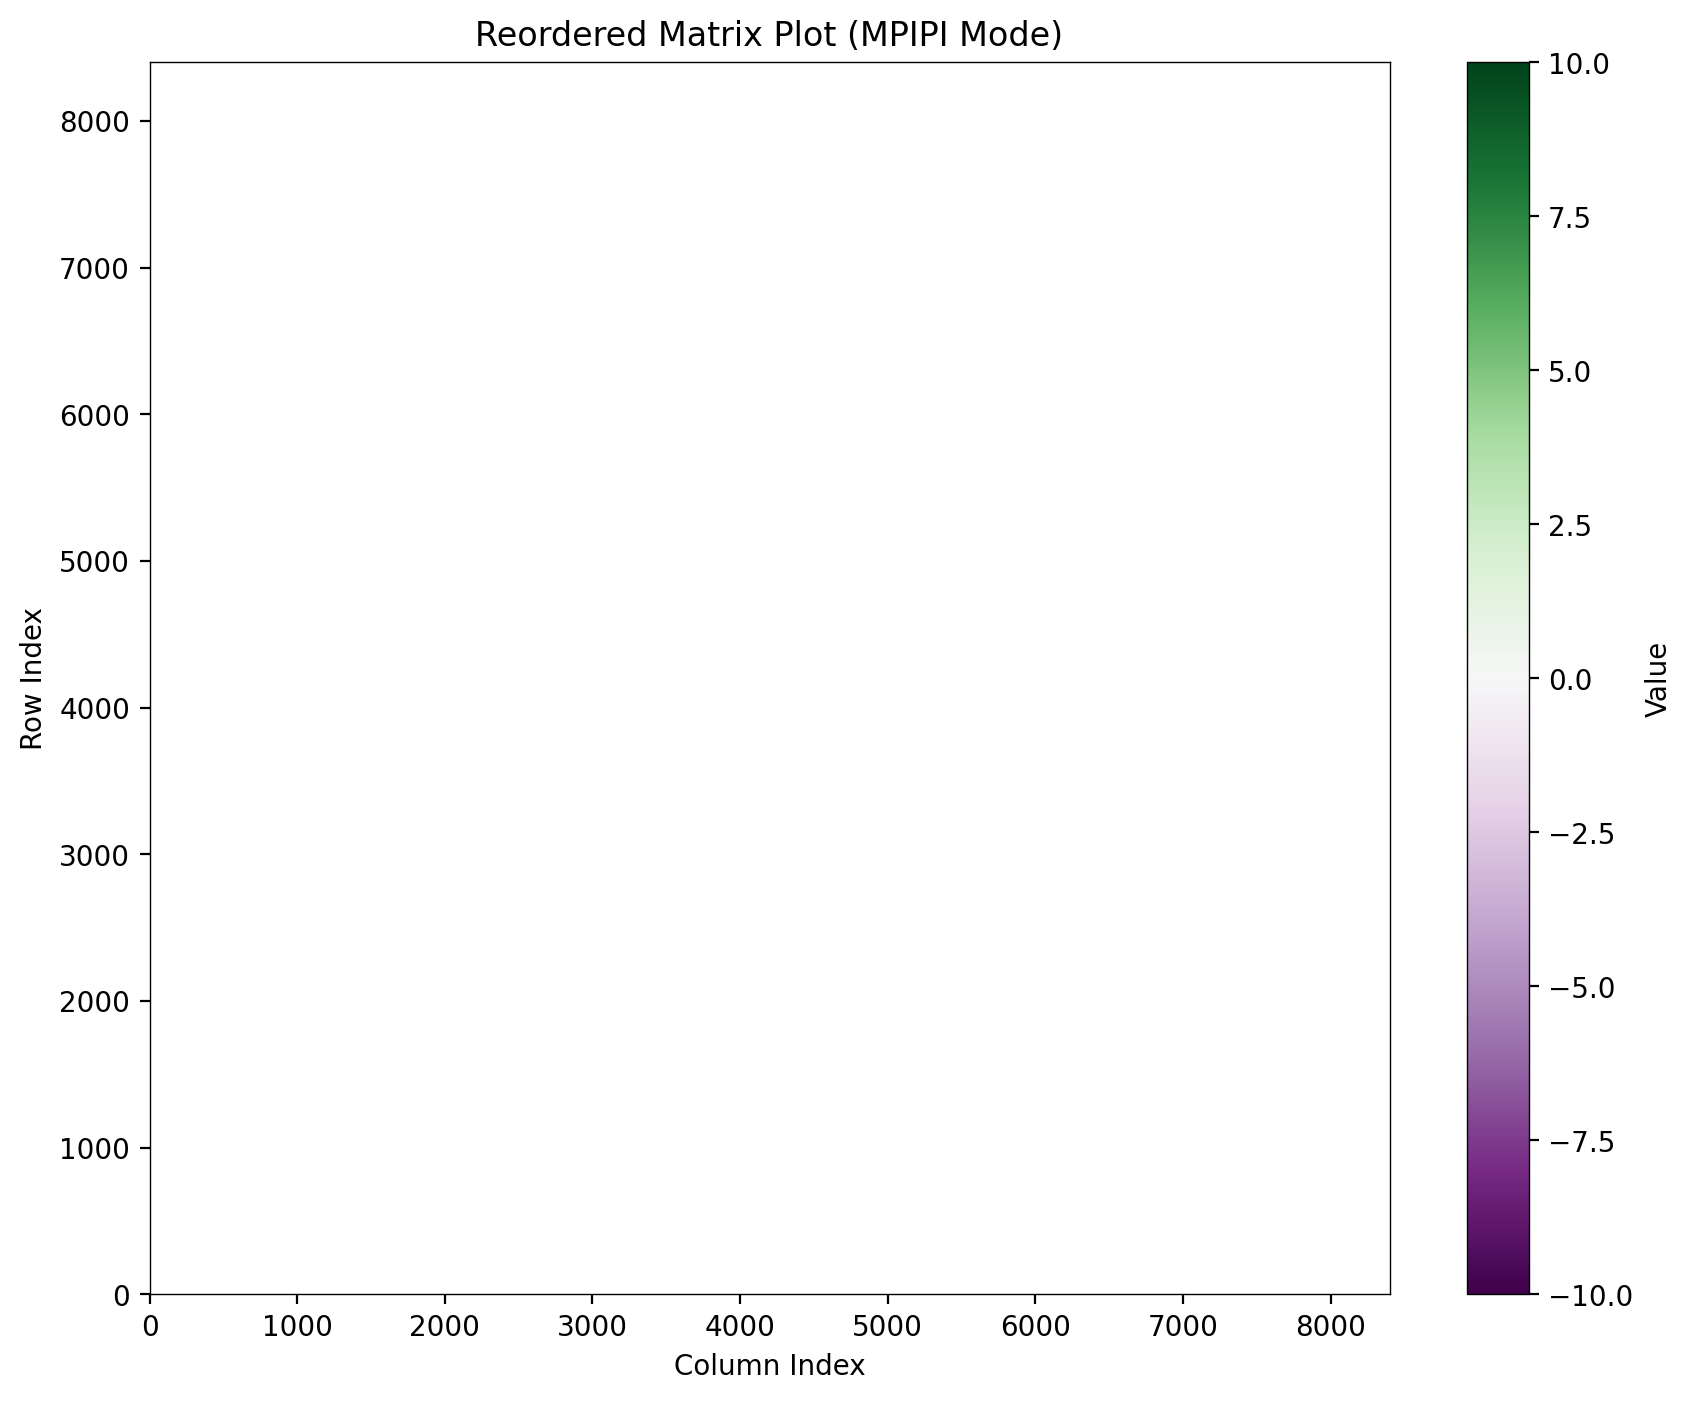

In [36]:
def plot_matrix_mpipi(df_matrix: pd.DataFrame, mode: str = 'mpipi'):
    """
    Plots a reordered matrix using imshow for 'mpipi' mode.

    Args:
        df_matrix (pd.DataFrame): The DataFrame representing the reordered matrix.
        mode (str): The plotting mode. Currently only 'mpipi' is handled.
    """
    if mode == 'mpipi':
        plt.figure(figsize=(10, 8)) # You can adjust the figure size as needed
        plt.imshow(df_matrix.values, vmin=-10, vmax=10, cmap='PRGn', interpolation='None', aspect='auto', origin='lower')
        plt.colorbar(label='Value') # Add a label to the color bar
        plt.title(f"Reordered Matrix Plot ({mode.upper()} Mode)") # Add a title
        plt.xlabel('Column Index') # Add x-label
        plt.ylabel('Row Index') # Add y-label
        plt.show()
    else:
        print(f"Plotting mode '{mode}' not supported by this function.")

# --- Example Usage ---
# Create a sample DataFrame to simulate 'reordered_matrix'
# Replace this with your actual reordered_matrix DataFrame



print("Sample DataFrame head:")
display(reordered_matrix.head())

# Call the function to plot the sample DataFrame
plot_matrix_mpipi(reordered_matrix, mode='mpipi')

Sample DataFrame head:


,3404,4089,2204,4582,3045,4201,97,1549,1531,2783,...,5054,5876,6220,5584,6195,5815,4629,6122,5802,5172
3404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


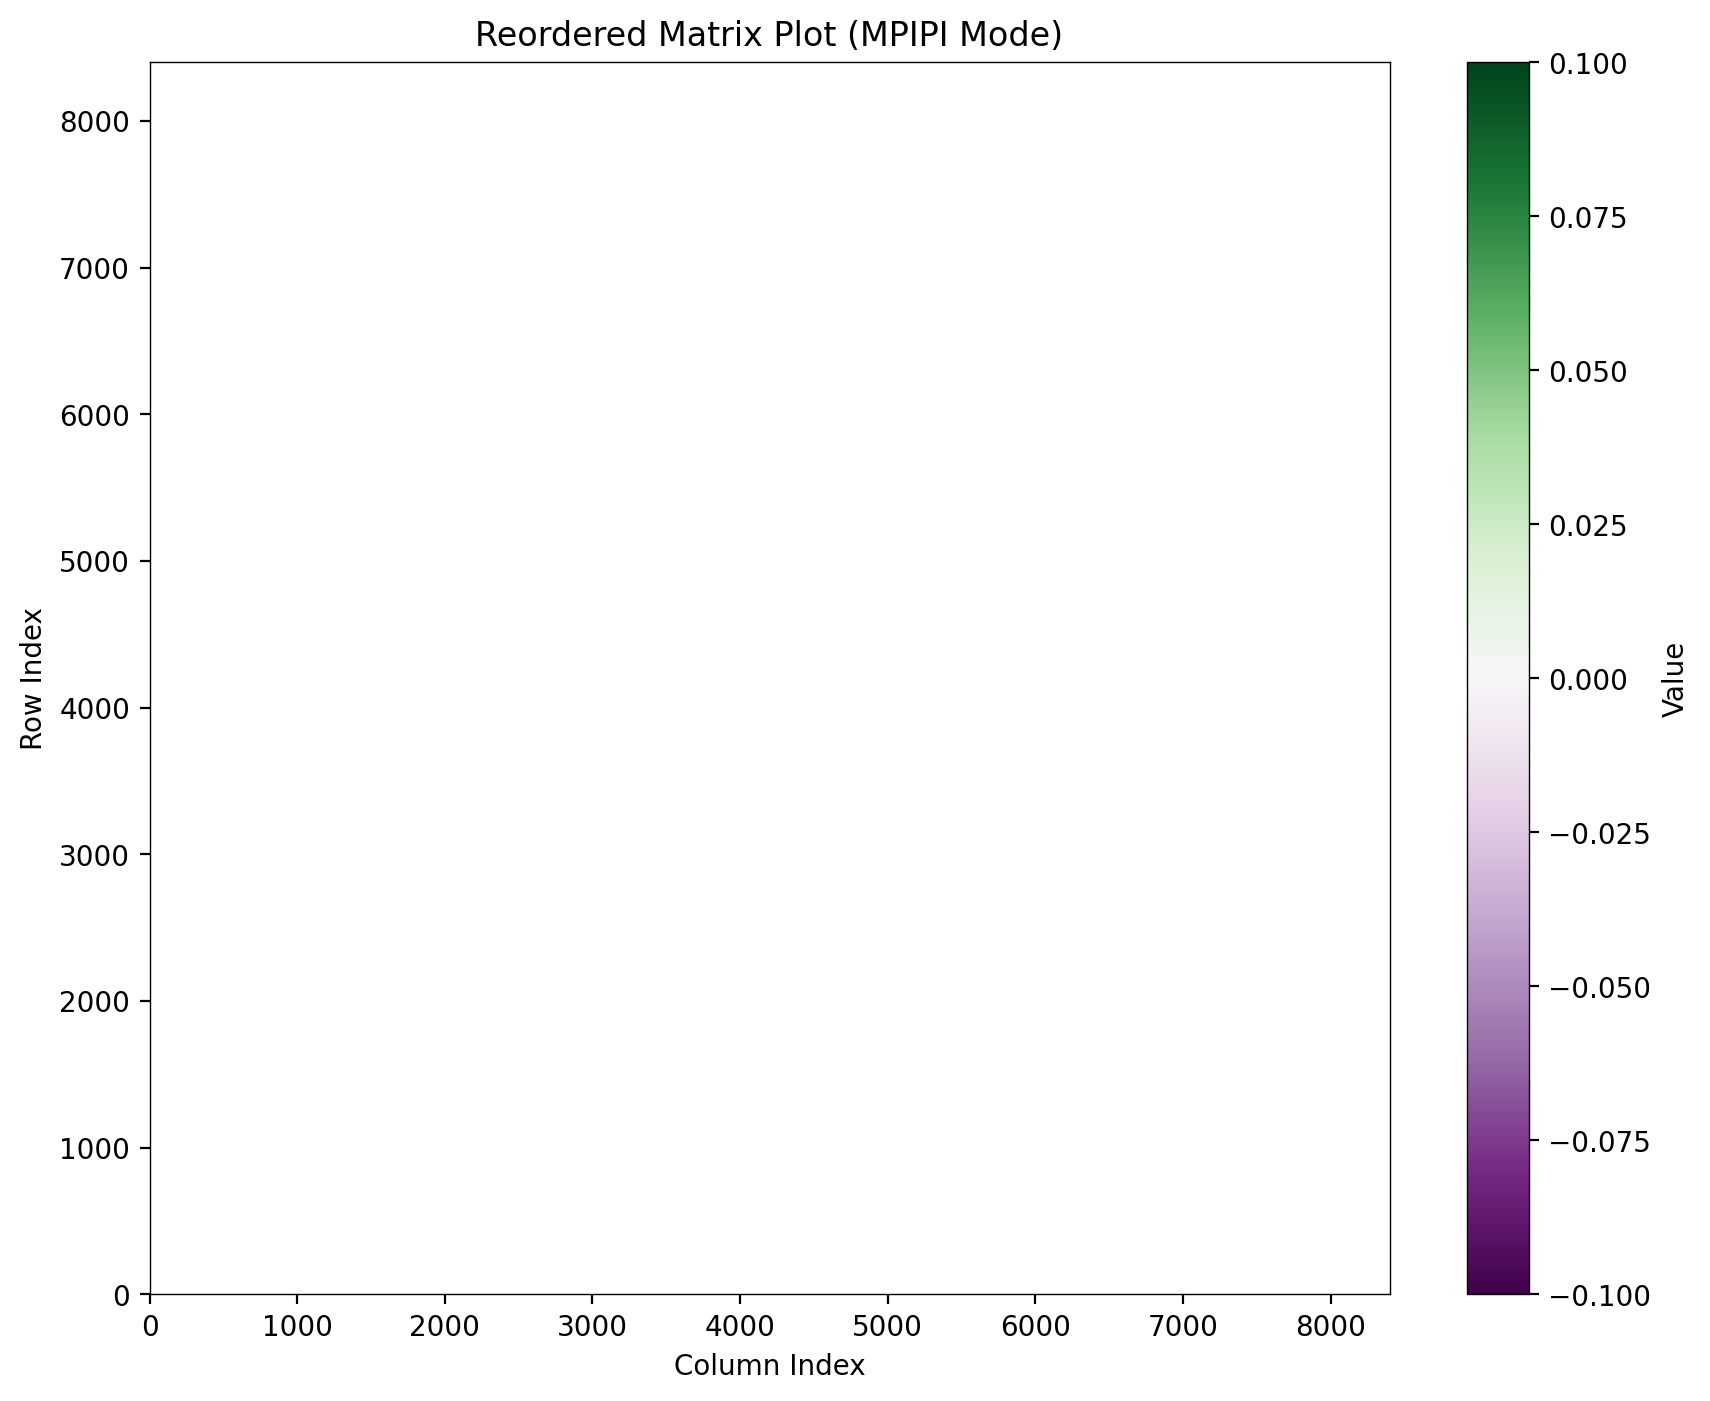

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_matrix_mpipi(df_matrix, mode: str = 'mpipi', vmin=None, vmax=None):
    """
    Plots a reordered matrix using imshow for 'mpipi' mode.

    Args:
        df_matrix (pd.DataFrame or np.ndarray): The DataFrame or NumPy array
                                                representing the reordered matrix.
        mode (str): The plotting mode. Currently only 'mpipi' is handled.
        vmin (float, optional): The minimum value for the colormap. If None, calculated from data.
        vmax (float, optional): The maximum value for the colormap. If None, calculated from data.
    """
    if mode == 'mpipi':
        plt.figure(figsize=(10, 8)) # You can adjust the figure size as needed
        
        # Check if df_matrix is a DataFrame and extract values, otherwise assume it's already a NumPy array
        data_to_plot = df_matrix.values if isinstance(df_matrix, pd.DataFrame) else df_matrix

        # If vmin/vmax are not provided, calculate them from the data
        if vmin is None:
            vmin = np.min(data_to_plot)
        if vmax is None:
            vmax = np.max(data_to_plot)

        plt.imshow(data_to_plot, vmin=vmin, vmax=vmax, cmap='PRGn', interpolation='None', aspect='auto', origin='lower')
        plt.colorbar(label='Value') # Add a label to the color bar
        plt.title(f"Reordered Matrix Plot ({mode.upper()} Mode)") # Add a title
        plt.xlabel('Column Index') # Add x-label
        plt.ylabel('Row Index') # Add y-label
        plt.show()
    else:
        print(f"Plotting mode '{mode}' not supported by this function.")

# --- Example Usage ---
# Create a sample DataFrame to simulate 'reordered_matrix'
# Replace this with your actual reordered_matrix DataFrame

# For demonstration, let's create a random matrix
sample_data = np.random.rand(15, 20) * 20 - 10 # Values between -10 and 10
sample_df = pd.DataFrame(sample_data,
                           index=[f'row_{i}' for i in range(15)],
                           columns=[f'col_{j}' for j in range(20)])

print("Sample DataFrame head:")
display(reordered_matrix.head())

# Call the function to plot the sample DataFrame without specifying vmin/vmax
# They will be calculated automatically based on sample_data's range
plot_matrix_mpipi(reordered_matrix, mode='mpipi')

# Example with custom vmin/vmax if needed
# plot_matrix_mpipi(sample_df, mode='mpipi', vmin=-5, vmax=5)

In [40]:
import plotly.express as px

# Replace 'df', 'x', and 'y' with your actual variables
fig = px.density_heatmap(reordered_matrix, x="x_column", y="y_column", 
                         nbinsx=30, nbinsy=30, 
                         color_continuous_scale="Viridis")
fig.show()

ModuleNotFoundError: No module named 'plotly'

In [39]:
import plotly.express as px
fig = px.density_heatmap(reordered_matrix, x='X', y='index')
fig.show()

ModuleNotFoundError: No module named 'plotly'

In [67]:
# define the number of clusters (0.5) - so nclusters12 => 24 clusters
nclusters=3

# find nclusters*2 clusters using maxclust
#clusters = fcluster(row_linkage, t=nclusters*2, criterion='maxclust')
clusters = fcluster(row_linkage, t=3, criterion='maxclust')

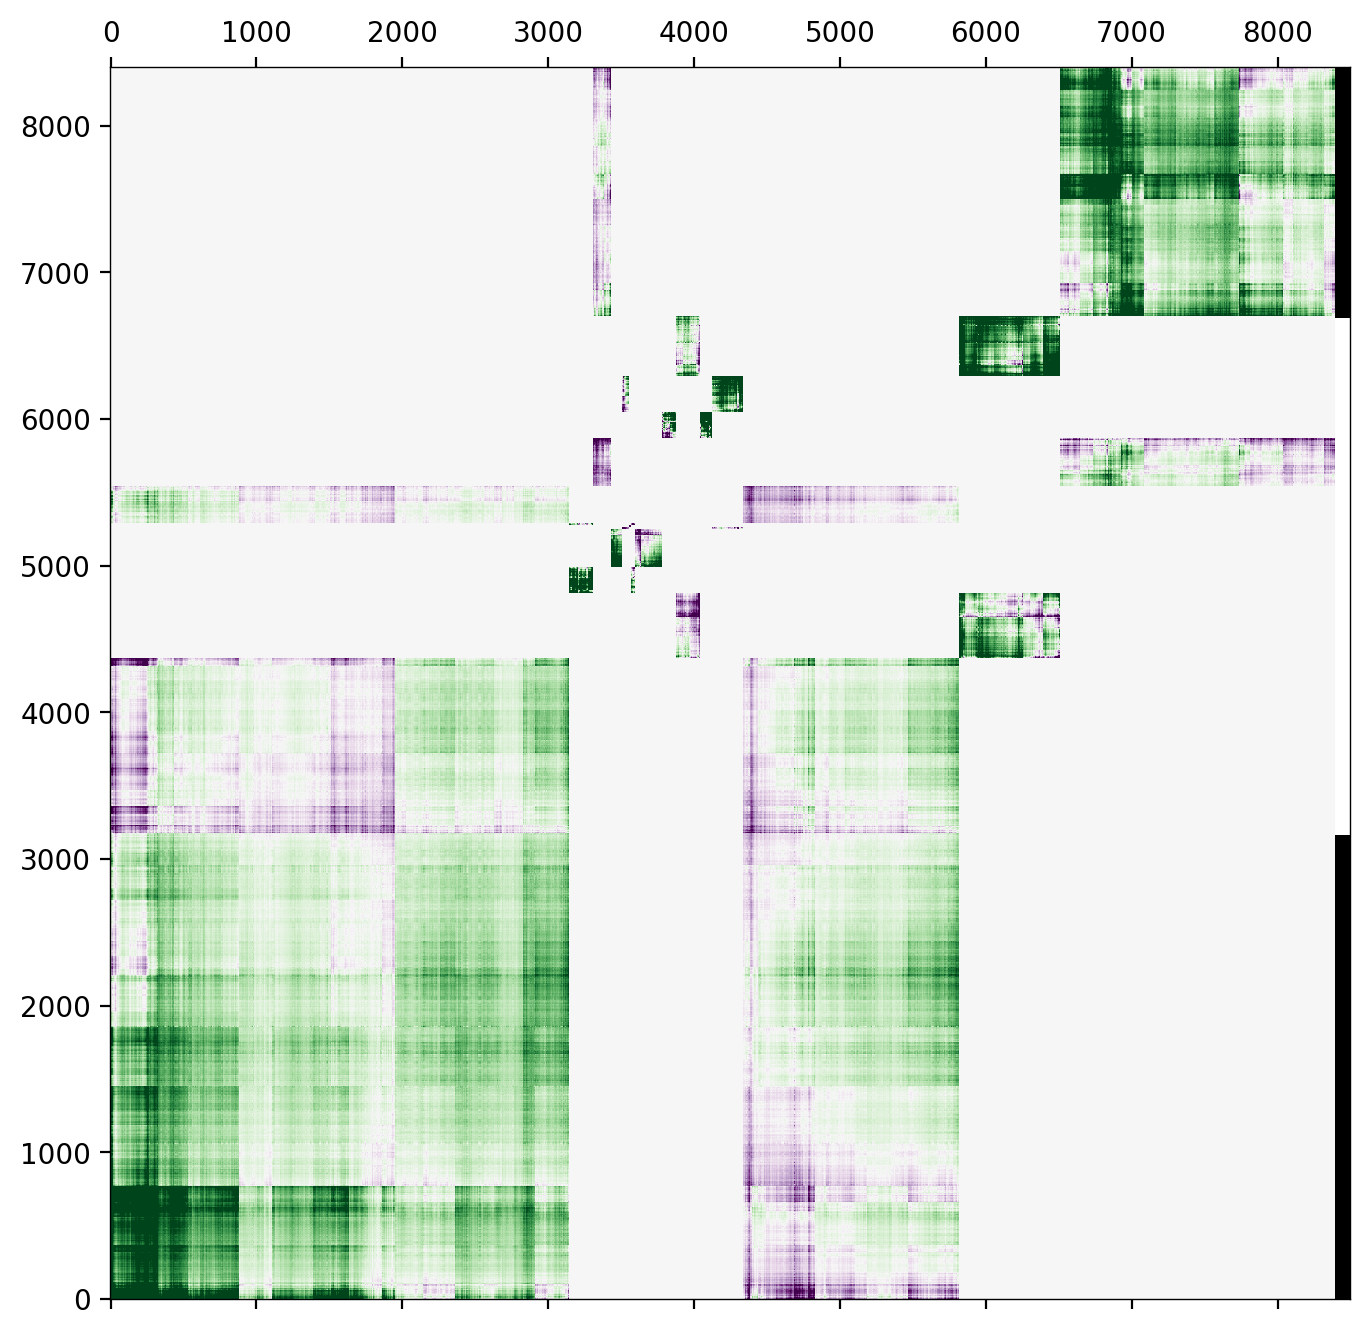

In [116]:
fig, ax = plt.subplots(figsize=(8, 8))

if mode == 'mpipi':
    cax = ax.matshow(reordered_matrix, aspect='auto', origin='lower', cmap='PRGn', vmin=-8, vmax=8)
elif mode == 'calvados':
    cax = ax.matshow(reordered_matrix, aspect='auto', origin='lower', cmap='PRGn', vmin=-25, vmax=25)

# Add a color bar for the heatmap

# cluster membership sidebar - rather than the chaos of a dendrogram we're gonna alternative white/black to deliniate
# cluster identity

possible_colors = ['k','w']
color_idx = 0

current_cluster = clusters[row_order][0]
current_color = 'k'
color_labels = []
color_labels.append(current_color)

for c in clusters[row_order][1:]:
    if c == current_cluster:
         pass
    else:
        current_cluster = c
        
        if color_idx + 1 == len(possible_colors):
            color_idx = 0
            current_color = possible_colors[color_idx]
        else:
            color_idx = color_idx + 1            
            current_color = possible_colors[color_idx]
        
    color_labels.append(current_color)


#cluster_colors = ['k', 'w']*(nclusters)
#color_labels = [cluster_colors[i-1] for i in clusters[row_order]]  # Match cluster ID to color

for ypos, c in enumerate(color_labels):
    ax.add_patch(mpatches.Rectangle((8400, ypos), 100, 10, color=c, edgecolor=None))

ax.set_xlim(right=reordered_matrix.shape[0]+100)

plt.savefig(f'/home/wenyuantong/Desktop/figures/3_cluster_unknown_matrix_{mode}.pdf')

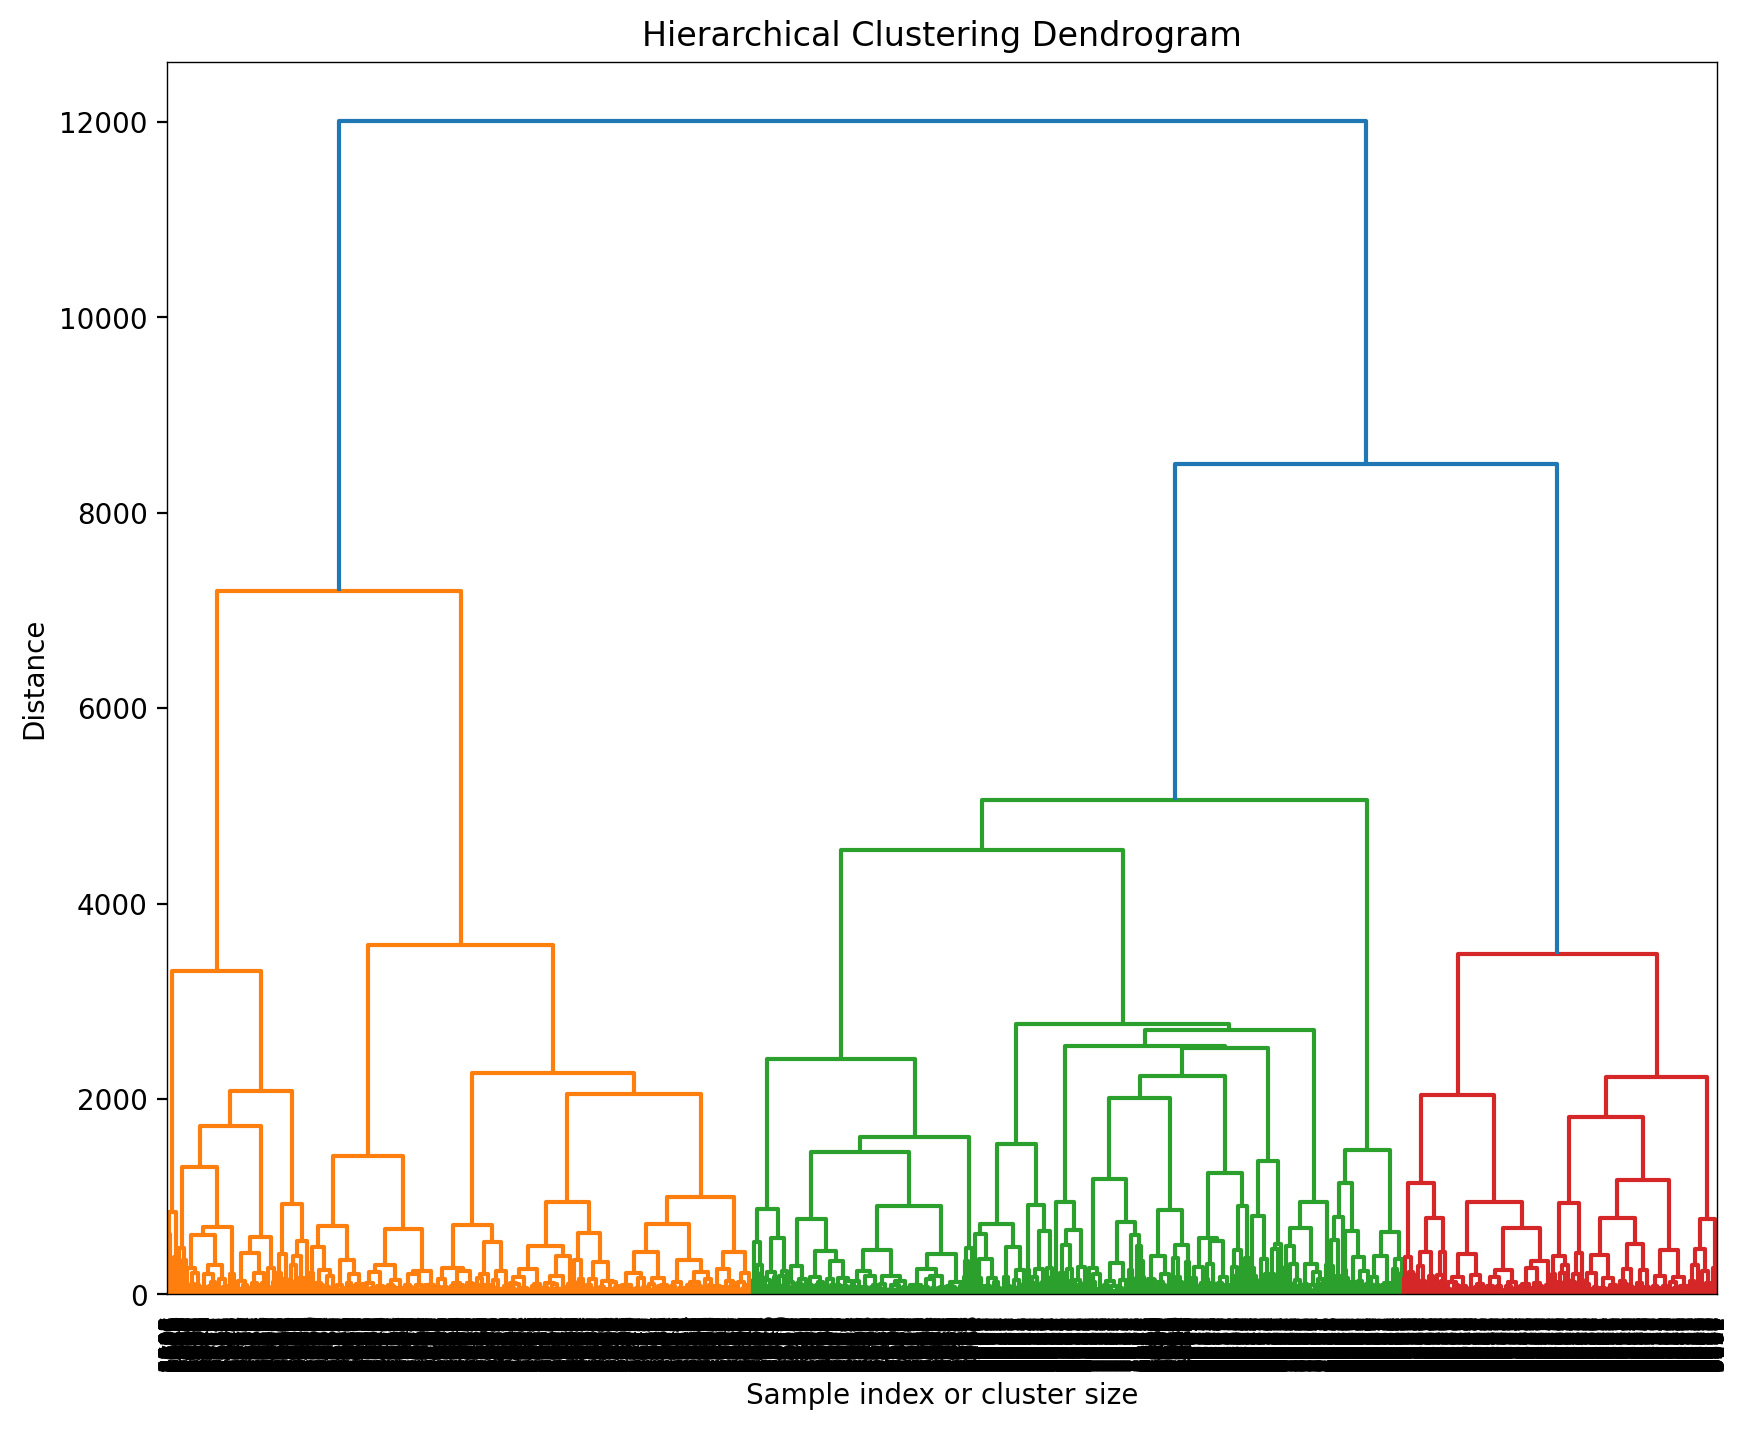

In [31]:
#Z = linkage(X, 'ward')
#row_linkage
#col_linkage

# 3. Plot the dendrogram
plt.figure(figsize=(10, 8))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index or cluster size')
plt.ylabel('Distance')

dendrogram(
    row_linkage,
    leaf_rotation=90.,  # Rotates the x-axis labels
    leaf_font_size=8.,  # Adjusts the font size for the labels
)

plt.show()

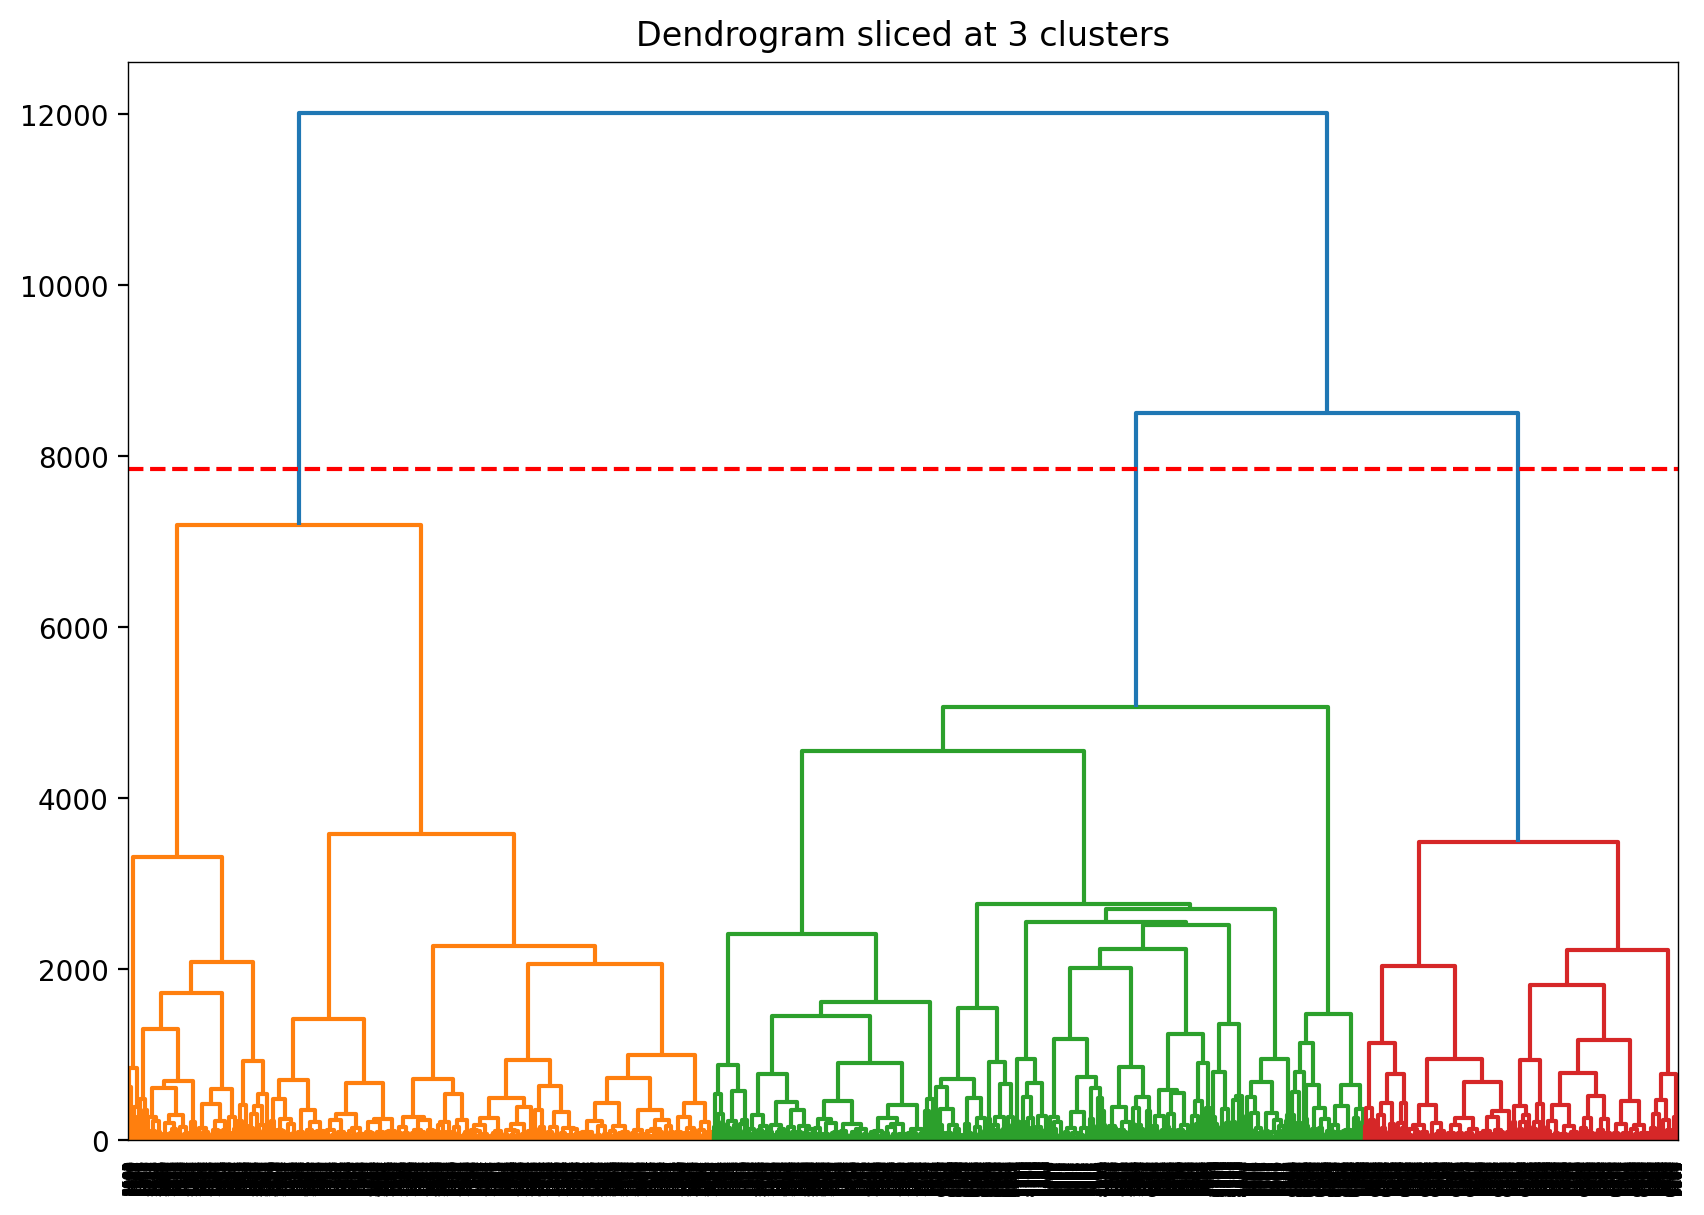

In [117]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Assuming Z is your linkage matrix and k is the number of clusters
Z = row_linkage
k = 3

# 1. Calculate the height threshold for k clusters
# The (n-k)th merge distance in Z[:, 2] determines the split
height = (Z[-(k), 2] + Z[-(k-1), 2]) / 2

# 2. Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(Z)

# 3. Add the horizontal slice line
plt.axhline(y=height, color='r', linestyle='--')
plt.title(f'Dendrogram sliced at {k} clusters')
plt.savefig('/home/wenyuantong/Desktop/figures/dendrogram_unknown_plot_3.png')
plt.show()

In [70]:
cluster_indices_dict = {}
for index, cluster_id in enumerate(clusters):
    if cluster_id not in cluster_indices_dict:
        cluster_indices_dict[cluster_id] = []
    cluster_indices_dict[cluster_id].append(index)

In [113]:
value = cluster_indices_dict[3]

In [108]:
value[:10]

[4622, 4623, 4624, 4625, 4627, 4628, 4629, 4630, 4631, 4633]

In [109]:
column_names_at_indices = df_filtered_partial.columns[value].tolist()

In [110]:
# Process the list to keep only the front part before the first underscore
processed_strings = []
for s in column_names_at_indices:
    # Split the string at the first underscore and take the first part
    front_part = s.split('_', 1)[0]
    processed_strings.append(front_part)

#print("\nProcessed list (front part only):")
#print(processed_strings)


In [111]:
output_filename = '/home/wenyuantong/Downloads/unknown_3.txt'

with open(output_filename, 'w') as f:
    for item in processed_strings:
        f.write(f"{item}\n")

print(f"Successfully saved processed_strings to '{output_filename}'")


Successfully saved processed_strings to '/home/wenyuantong/Downloads/unknown_3.txt'


In [94]:
#cluster_indices_dict

#cluster_domains.type

for key, value in cluster_indices_dict.items():
    first_key, first_val = key, value
    print(first_key)
    #print(first_val[-100:])
    print(first_val[:100])
    #row_names = pd.Index(row_order_list_int, dtype=df_index_dtype)
    column_names_at_indices = df_filtered_partial.columns[first_val].tolist()
    print(column_names_at_indices)
    break

#print(first_key)
#print(first_val[:100])

2
[0, 1, 3, 6, 8, 11, 13, 16, 21, 23, 24, 29, 36, 41, 53, 60, 62, 65, 67, 71, 75, 76, 79, 81, 87, 88, 90, 92, 95, 101, 102, 106, 107, 116, 120, 121, 125, 126, 127, 131, 134, 137, 148, 149, 155, 156, 158, 160, 162, 164, 169, 173, 175, 176, 177, 180, 181, 190, 193, 205, 206, 207, 208, 209, 210, 214, 218, 220, 221, 224, 225, 233, 235, 236, 237, 238, 240, 244, 245, 246, 247, 252, 255, 261, 264, 266, 267, 270, 271, 275, 277, 279, 282, 291, 295, 298, 301, 310, 312, 318]
['A0A1P8B415_N-terminal_1_66', 'F4JTS9_N-terminal_1_58', 'O64764_N-terminal_1_84', 'Q8L9H6_IDP_1_99', 'Q8RXJ5_N-terminal_1_51', 'Q9LS03_N-terminal_1_82', 'Q9LVR0_N-terminal_1_76', 'Q9ZVI9_N-terminal_1_52', 'Q45GK4_N-terminal_1_76', 'Q93W95_N-terminal_1_60', 'Q9FLJ3_IDP_1_77', 'Q9SKP6_N-terminal_1_56', 'Q7Y205_IDP_1_84', 'Q9M0G4_N-terminal_1_56', 'Q4TU14_C-terminal_316_371', 'Q9LPF5_N-terminal_1_61', 'Q9SKD3_N-terminal_1_83', 'A0A1P8B4L7_IDP_1_66', 'F4JQT1_N-terminal_1_52', 'O80757_C-terminal_270_327', 'Q67XV2_N-terminal_1_68'

In [93]:
cluster_indices_dict.items()[0]

TypeError: 'dict_items' object is not subscriptable

In [73]:
# define the domains in each cluster (1,2,... from bottom to top)
cluster_domains = {}
for i in range(1, 1+3):

    cluster_domains[i] = []
    for idx in cluster_indices_dict[i]:
        #cluster_domains[i].append(df_filtered_partial[idx])
        cluster_domains[i].append(reordered_matrix[idx])

In [83]:
#cluster_domains.type

for key, value in cluster_domains.items():
    first_key, first_val = key, value
    break

print(first_key)
print(first_val[:1])

1
[3404    22.931006
3045    21.013645
2204    19.655830
4582    17.121245
3445    17.768859
          ...    
5815     0.000000
4629     0.000000
5481     0.000000
5802     0.000000
5172     0.000000
Name: 2, Length: 8400, dtype: float64]


In [74]:
cluster_fasta = {}
for i in range(1, 1+3):
    for d in cluster_domains[i]:
        name = f"CLUSTER_{i} | {d.protein.name} | START={d.start}  END={d.end}"
        seq = d.sequence
        cluster_fasta[name] = seq
        
protfasta.write_fasta(cluster_fasta, f'/home/wenyuantong/Desktop/data/LMP_unknown_clustered_idrs_{mode}.fasta') 

AttributeError: 'Series' object has no attribute 'protein'